# Customer Intelligence & Financial Analytics Dashboard

## Business Problem

Businesses collect large volumes of customer transaction data, but transforming that data into actionable insights remains a challenge. This project analyzes customer shopping behavior to identify purchasing patterns, customer segments, revenue opportunities, and strategic business recommendations.

## Objectives

- Perform data cleaning and preprocessing.
- Conduct exploratory data analysis (EDA).
- Analyze customer behavior using SQL.
- Engineer business-focused features such as Customer Lifetime Value (CLV) and Customer Health Score.
- Segment customers using K-Means clustering.
- Build an interactive Power BI dashboard for executive decision-making.

## Tech Stack

- Python
- SQL
- Power BI
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-learn

---

In [ ]:
# Loading the dataset using pandas

import pandas as pd

df = pd.read_csv('customer_shopping_behavior.csv')

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

## Dataset Overview

The dataset contains customer demographic information, purchasing behavior, product preferences, payment methods, discount usage, and customer feedback. The objective is to analyze customer behavior and generate actionable business insights that support data-driven decision-making.

In [ ]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])


Rows : 3900
Columns : 18


In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [ ]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [ ]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

## Data Quality Assessment

Before performing analysis, the dataset is evaluated for missing values, duplicate records, column consistency, and data types to ensure reliable business insights.

In [ ]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [ ]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [ ]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [ ]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [ ]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [ ]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

This validation checks whether customers receiving discounts are the same as those using promotional codes. If both columns contain identical information, one of them may be redundant.

In [ ]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [ ]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [ ]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-aged,365


In [ ]:
df.shape

(3900, 19)

# Exploratory Data Analysis (EDA)

The objective of this section is to explore customer demographics, purchasing behavior, and revenue trends to identify actionable business insights.

In [ ]:
print("Numerical Columns")
display(df.select_dtypes(include=['int64', 'float64']).columns)

print("\nCategorical Columns")
display(df.select_dtypes(include='object').columns)

Numerical Columns


Index(['customer_id', 'age', 'purchase_amount', 'review_rating',
       'previous_purchases', 'purchase_frequency_days'],
      dtype='object')


Categorical Columns


Index(['gender', 'item_purchased', 'category', 'location', 'size', 'color',
       'season', 'subscription_status', 'shipping_type', 'discount_applied',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

# Business Questions

This analysis aims to answer the following questions:

1. What is the demographic profile of customers?
2. Which customer groups generate the highest revenue?
3. Which product categories perform the best?
4. Which payment methods are most preferred?
5. Does discount usage influence customer purchases?
6. Which customer segments should businesses target?
7. What business strategies can improve customer retention and profitability?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

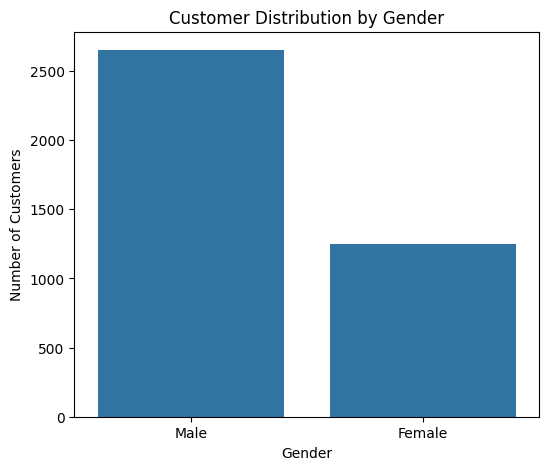

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='gender')

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

This visualization shows the gender distribution of customers. A balanced distribution indicates that marketing campaigns should be designed to appeal to both genders, while a significant imbalance may highlight opportunities for targeted marketing strategies.

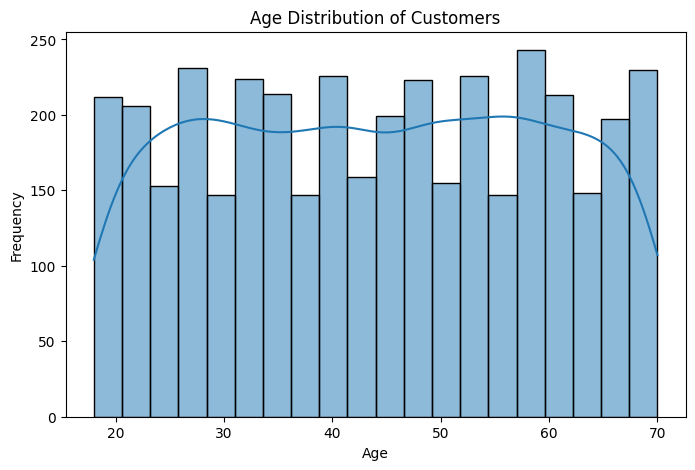

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Business Insight

Understanding the age distribution helps identify the primary customer demographic and supports age-specific marketing, product recommendations, and promotional campaigns.

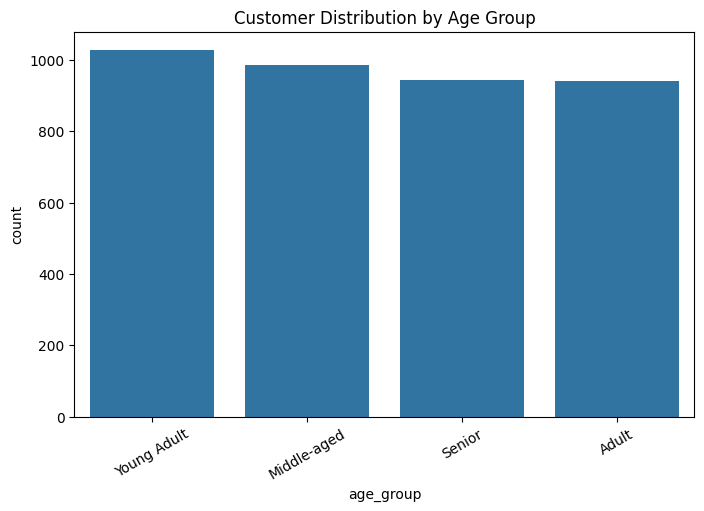

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='age_group',
    order=df['age_group'].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Customer Distribution by Age Group")

plt.show()

### Business Insight

Grouping customers by age simplifies demographic analysis and helps businesses understand which age segments contribute the largest customer base.

## Purchase Amount Distribution

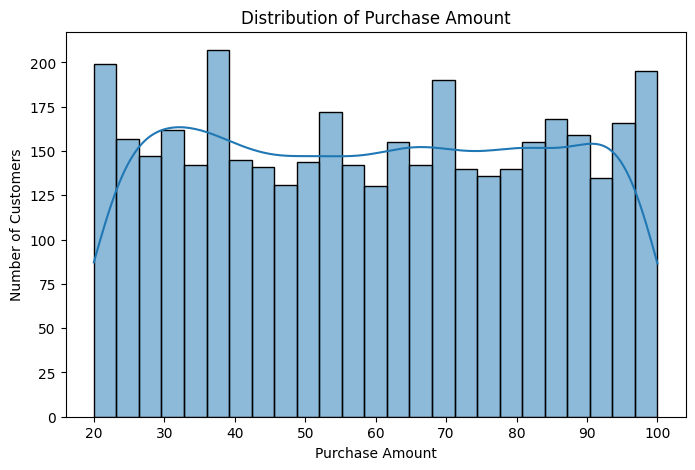

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['purchase_amount'], bins=25, kde=True)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

This visualization illustrates how customer spending is distributed. It helps identify whether most customers make low-value purchases or whether spending is evenly distributed across different purchase ranges.

### Business Recommendation

If the majority of purchases fall within lower spending ranges, businesses can introduce bundled offers, loyalty rewards, or personalized recommendations to encourage higher-value purchases.

## Revenue by Product Category

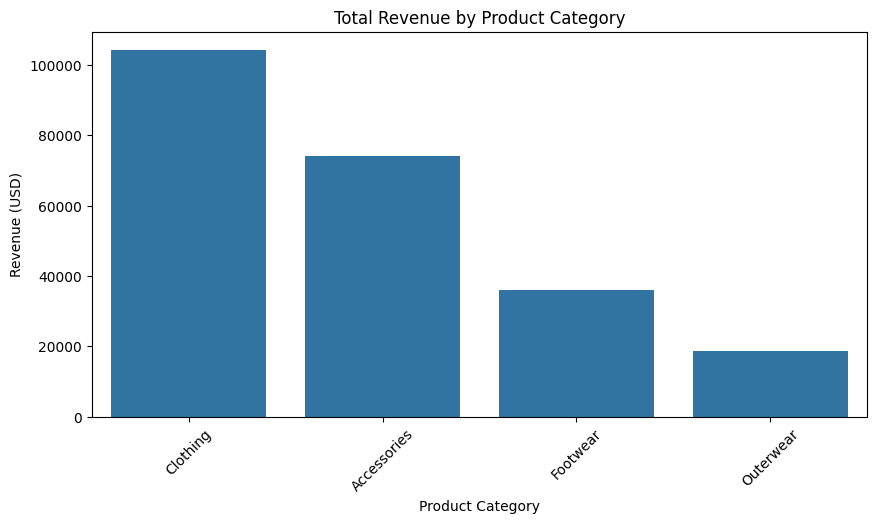

In [ ]:
category_revenue = (
    df.groupby('category')['purchase_amount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.xticks(rotation=45)

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue (USD)")

plt.show()

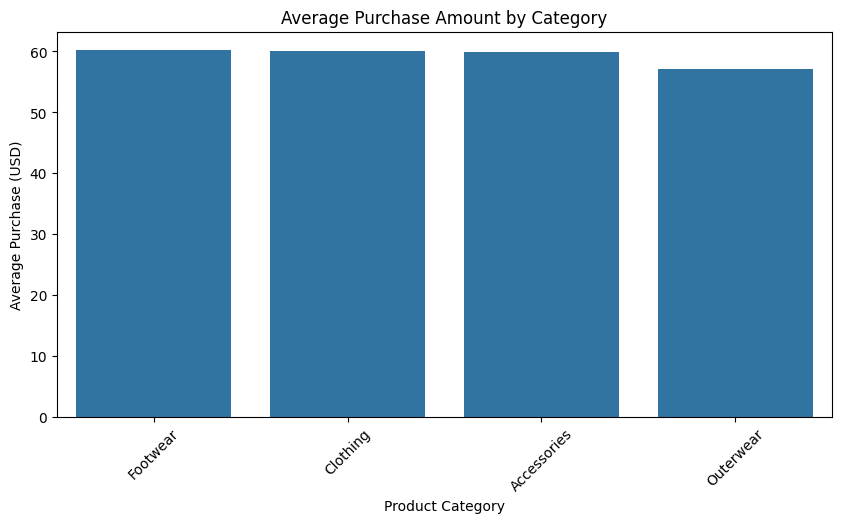

In [ ]:
avg_purchase = (
    df.groupby('category')['purchase_amount']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_purchase.index,
    y=avg_purchase.values
)

plt.xticks(rotation=45)

plt.title("Average Purchase Amount by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Purchase (USD)")

plt.show()

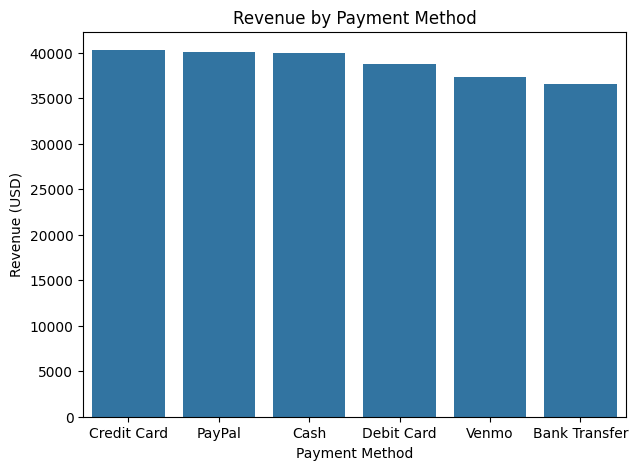

In [ ]:
payment_revenue = (
    df.groupby('payment_method')['purchase_amount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (USD)")

plt.show()

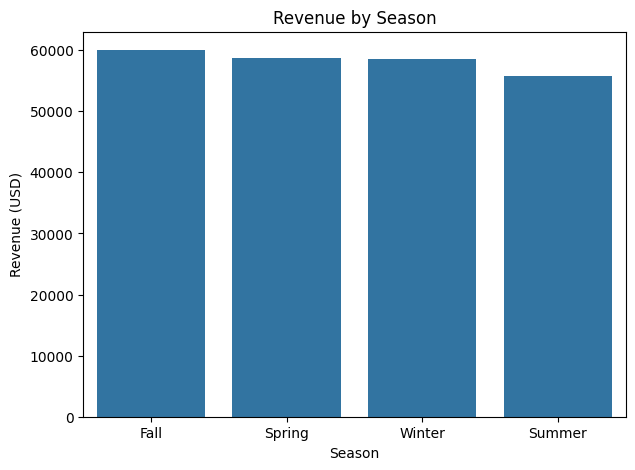

In [ ]:
season_revenue = (
    df.groupby('season')['purchase_amount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=season_revenue.index,
    y=season_revenue.values
)

plt.title("Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue (USD)")

plt.show()

## Subscription Status Analysis

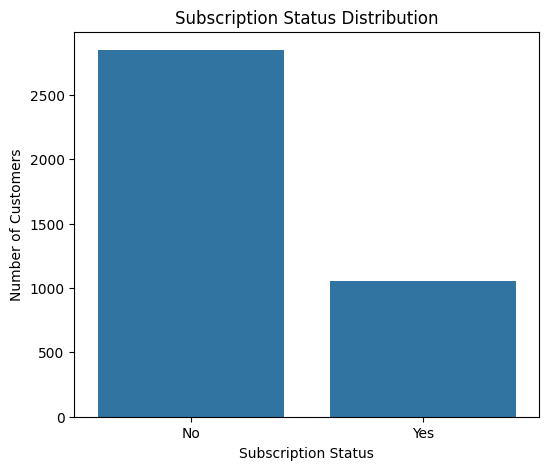

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='subscription_status',
    order=df['subscription_status'].value_counts().index
)

plt.title("Subscription Status Distribution")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

This visualization shows the proportion of subscribed and non-subscribed customers. A higher subscription rate generally indicates stronger customer loyalty and recurring business.

### Business Recommendation

If the number of non-subscribers is high, introduce exclusive membership benefits, discounts, and personalized offers to increase subscription adoption.

### Interview Talking Point

I analyzed subscription status to understand customer loyalty and identify opportunities for increasing recurring revenue.

## Discount Usage Analysis

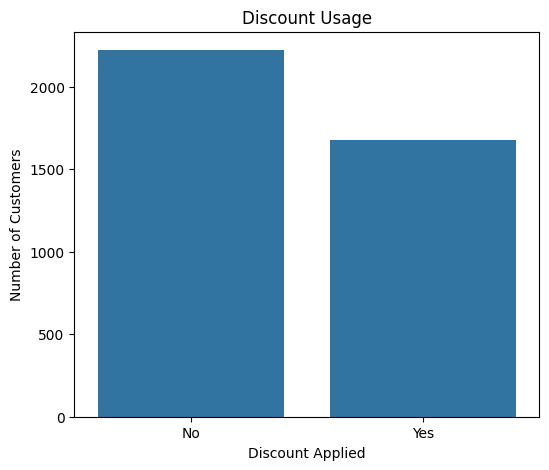

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='discount_applied',
    order=df['discount_applied'].value_counts().index
)

plt.title("Discount Usage")
plt.xlabel("Discount Applied")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

This chart highlights how frequently discounts are used during purchases and helps evaluate customers' dependence on promotional offers.

### Business Recommendation

If discount usage is very high, businesses should carefully evaluate pricing strategies to maintain profitability while retaining customers.

### Interview Talking Point

This analysis helps assess customer purchasing behavior and the effectiveness of promotional campaigns.

## Previous Purchases Analysis

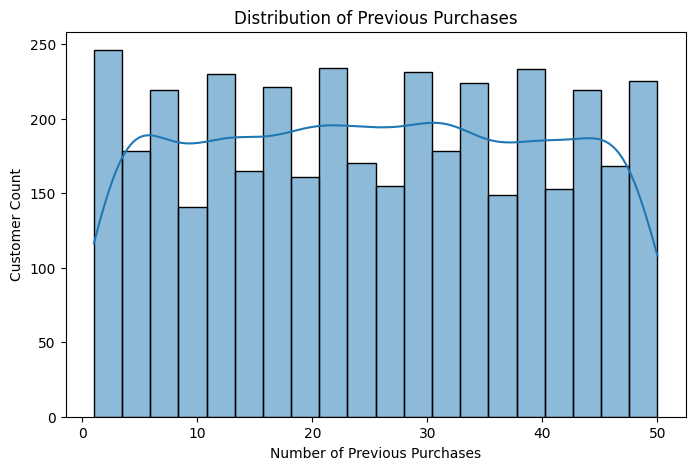

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['previous_purchases'], bins=20, kde=True)

plt.title("Distribution of Previous Purchases")
plt.xlabel("Number of Previous Purchases")
plt.ylabel("Customer Count")

plt.show()

### Business Insight

Customers with a higher number of previous purchases are generally more loyal and contribute significantly to business revenue.

### Business Recommendation

Reward loyal customers through personalized offers, loyalty points, or exclusive memberships to encourage repeat purchases.

### Interview Talking Point

I analyzed previous purchases to understand customer loyalty and identify repeat buyers.

## Shipping Preference Analysis

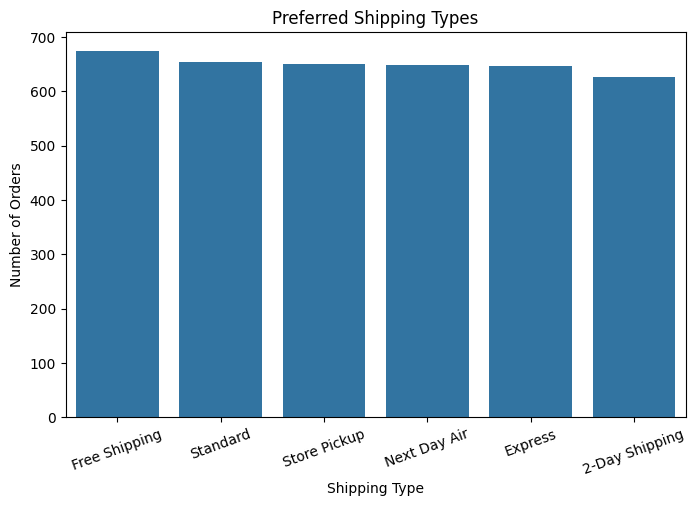

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='shipping_type',
    order=df['shipping_type'].value_counts().index
)

plt.xticks(rotation=20)

plt.title("Preferred Shipping Types")
plt.xlabel("Shipping Type")
plt.ylabel("Number of Orders")

plt.show()

### Business Insight

Shipping preferences help businesses optimize logistics operations and improve customer satisfaction.

### Business Recommendation

Invest in the most preferred shipping methods while ensuring less popular options remain cost-effective.

### Interview Talking Point

Shipping analysis helps identify customer delivery preferences and supports logistics optimization.

## Revenue by Location

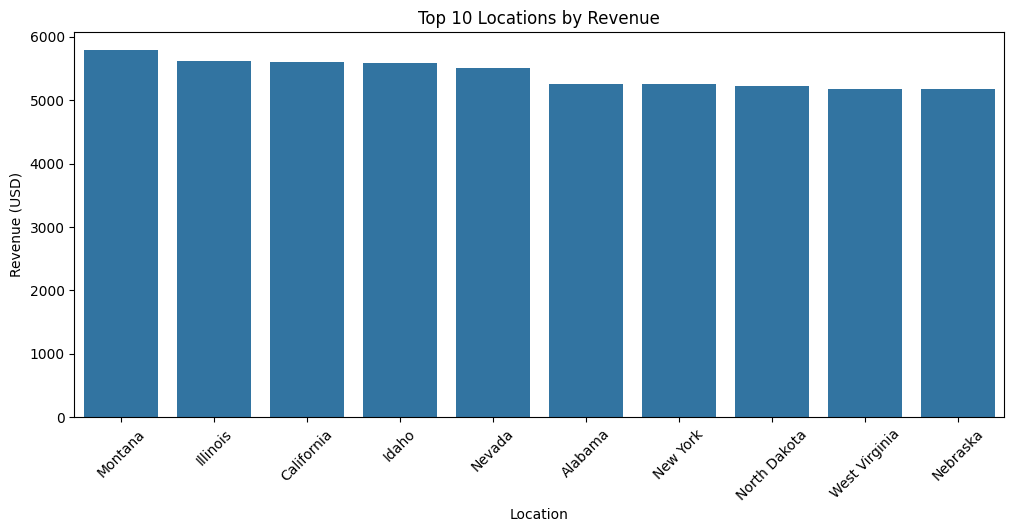

In [ ]:
location_revenue = (
    df.groupby('location')['purchase_amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=location_revenue.index,
    y=location_revenue.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Locations by Revenue")
plt.xlabel("Location")
plt.ylabel("Revenue (USD)")

plt.show()

### Business Insight

This visualization identifies the regions generating the highest revenue and helps prioritize business expansion and marketing investments.

### Business Recommendation

Focus promotional campaigns and inventory planning on high-performing regions while identifying growth opportunities in lower-performing markets.

### Interview Talking Point

This analysis helps businesses understand geographical revenue distribution and optimize regional business strategies.

## Customer Review Rating Analysis

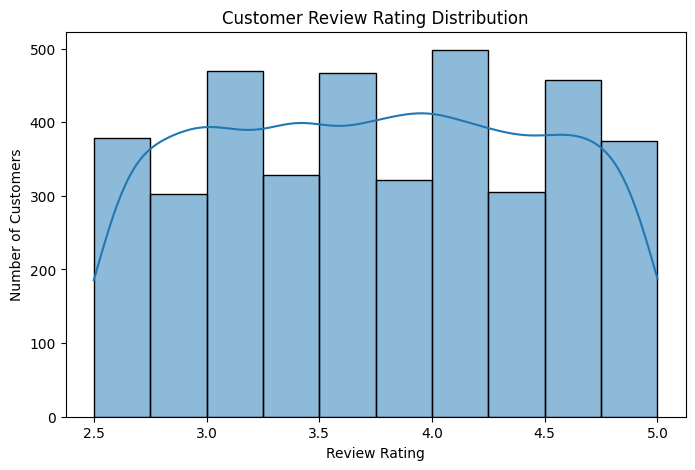

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['review_rating'], bins=10, kde=True)

plt.title("Customer Review Rating Distribution")
plt.xlabel("Review Rating")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Customer ratings provide valuable feedback about customer satisfaction and overall shopping experience.

### Business Recommendation

Products or services receiving consistently lower ratings should be investigated to identify improvement opportunities.

### Interview Talking Point

Review ratings help evaluate customer satisfaction and identify areas for improving products and services.

## Average Review Rating by Product Category

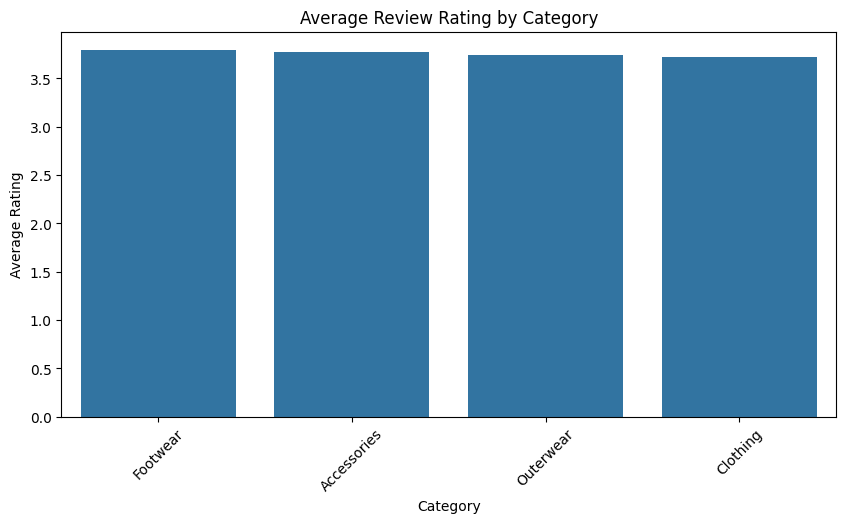

In [ ]:
category_rating = (
    df.groupby('category')['review_rating']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=category_rating.index,
    y=category_rating.values
)

plt.xticks(rotation=45)

plt.title("Average Review Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.show()

### Business Insight

Comparing average ratings across categories helps identify products that satisfy customers and those requiring quality improvements.

### Business Recommendation

Analyze lower-rated categories to improve product quality, pricing, or customer experience.

### Interview Talking Point

I created this visualization to identify categories with high and low customer satisfaction levels.

## Correlation Analysis

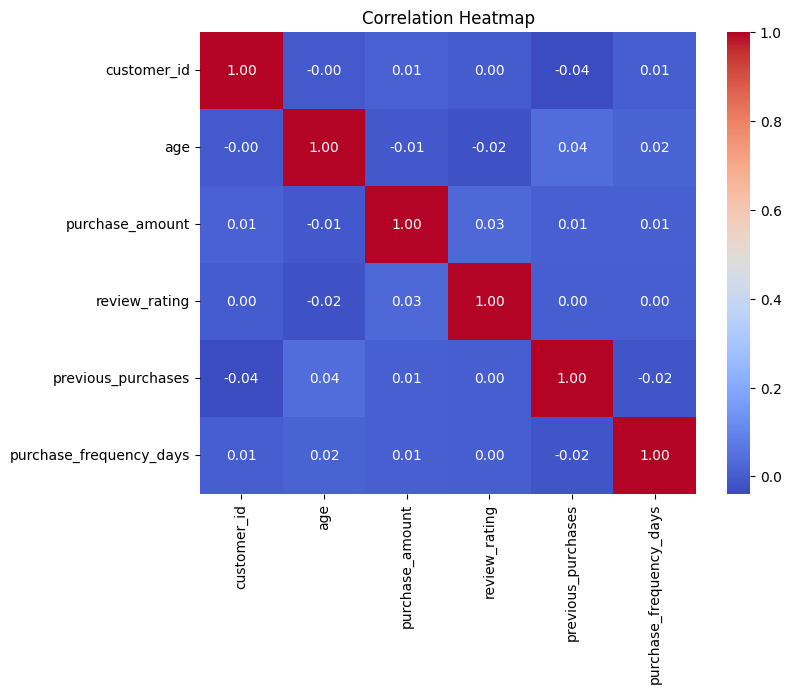

In [ ]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Business Insight

The heatmap highlights relationships among numerical variables and helps identify factors that may influence customer spending and purchasing behavior.

### Interview Talking Point

Correlation analysis is useful for identifying relationships between variables before performing advanced analytics or predictive modeling.

# EDA Summary

## Key Findings

- Customer purchases are distributed across multiple product categories, with a few categories contributing significantly higher revenue.
- Purchase behavior varies across age groups, locations, payment methods, and seasons.
- Subscription status and previous purchase history indicate opportunities for improving customer retention.
- Review ratings suggest generally positive customer satisfaction, while highlighting categories requiring further investigation.
- Correlation analysis shows weak to moderate relationships among numerical variables, indicating that customer behavior is influenced by multiple factors rather than a single variable.

## Conclusion

The exploratory analysis provides valuable insights into customer demographics, purchasing behavior, and financial performance. These findings form the foundation for advanced feature engineering, customer segmentation, and business intelligence analysis in the next phase.

In [ ]:
df['estimated_clv'] = (
    df['purchase_amount'] *
    (df['previous_purchases'] + 1)
)

In [ ]:
df[['customer_id',
    'purchase_amount',
    'previous_purchases',
    'estimated_clv']].head()

,customer_id,purchase_amount,previous_purchases,estimated_clv
0,1,53,14,795
1,2,64,2,192
2,3,73,23,1752
3,4,90,49,4500
4,5,49,31,1568


### Why Estimated CLV?

Since the dataset does not contain actual lifetime revenue, an estimated Customer Lifetime Value (CLV) is calculated using purchase amount and purchase history. This provides an approximate measure of long-term customer value.

In [ ]:
df['subscription_score'] = df['subscription_status'].map({
    'Yes': 10,
    'No': 0
})

df['loyalty_score'] = (
    df['previous_purchases']
    + df['subscription_score']
)

In [ ]:
df[['customer_id',
    'previous_purchases',
    'subscription_status',
    'loyalty_score']].head()

,customer_id,previous_purchases,subscription_status,loyalty_score
0,1,14,Yes,24
1,2,2,Yes,12
2,3,23,Yes,33
3,4,49,Yes,59
4,5,31,Yes,41


In [ ]:
df['customer_value_tier'] = pd.qcut(
    df['estimated_clv'],
    q=4,
    labels=[
        'Bronze',
        'Silver',
        'Gold',
        'Premium'
    ]
)

In [ ]:
df['customer_value_tier'].value_counts()

,count
customer_value_tier,
Silver,980
Bronze,975
Premium,974
Gold,971


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['purchase_norm',
    'review_norm',
    'previous_purchase_norm']] = scaler.fit_transform(
    df[['purchase_amount',
        'review_rating',
        'previous_purchases']]
)

In [ ]:
df['subscription_numeric'] = df['subscription_status'].map({
    'Yes': 1,
    'No': 0
})

In [ ]:
df['customer_health_score'] = (
    0.4 * df['purchase_norm']
    + 0.3 * df['previous_purchase_norm']
    + 0.2 * df['review_norm']
    + 0.1 * df['subscription_numeric']
)

df['customer_health_score'] = (
    df['customer_health_score'] * 100
).round(2)

In [ ]:
df[['customer_id',
    'customer_health_score']].head()

,customer_id,customer_health_score
0,1,39.26
1,2,37.41
2,3,54.77
3,4,82.39
4,5,44.47


### Customer Health Score

The Customer Health Score combines purchase behavior, customer satisfaction, purchase history, and subscription status into a single metric ranging from 0 to 100. It provides an overall indicator of customer value and engagement.

In [ ]:
df['health_status'] = pd.cut(
    df['customer_health_score'],
    bins=[0,40,60,80,100],
    labels=[
        'At Risk',
        'Average',
        'Healthy',
        'Excellent'
    ]
)

In [ ]:
df['health_status'].value_counts()

,count
health_status,
Average,1677
At Risk,1323
Healthy,800
Excellent,100


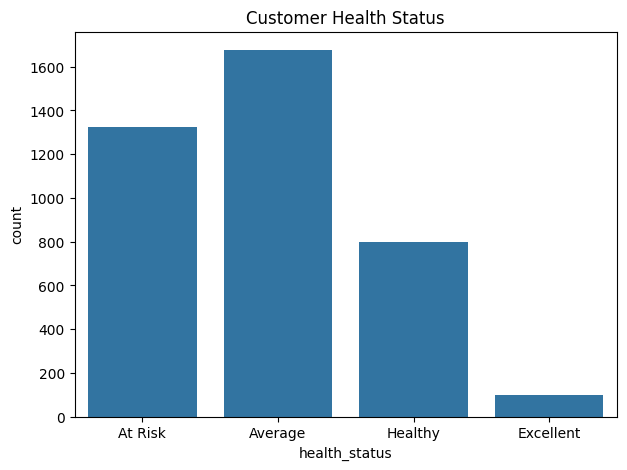

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='health_status',
    order=['At Risk','Average','Healthy','Excellent']
)

plt.title("Customer Health Status")

plt.show()

### Business Insight

Customer Health Status summarizes customer engagement and value. Customers categorized as "Excellent" are highly valuable and should be retained, while "At Risk" customers may require targeted retention strategies.

### Business Recommendation

Provide personalized offers and loyalty programs for high-value customers while designing re-engagement campaigns for customers identified as At Risk.

### Interview Talking Point

I created a Customer Health Score to combine multiple customer behavior indicators into a single business metric, enabling easier segmentation and strategic decision-making.

/tmp/ipykernel_1021/2051184200.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_value_tier')['purchase_amount']


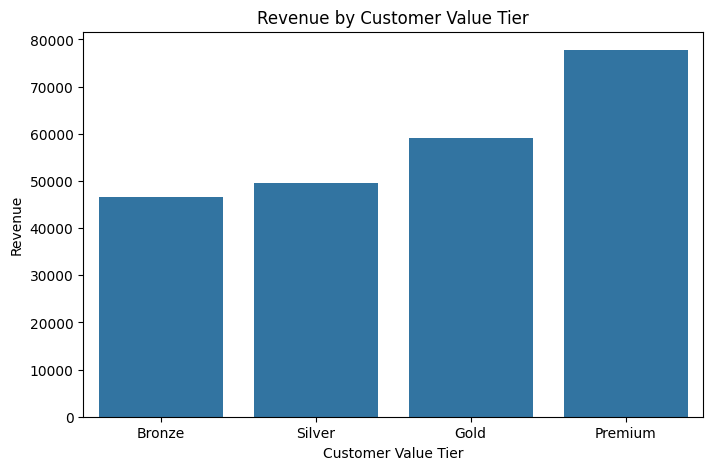

In [ ]:
tier_revenue = (
    df.groupby('customer_value_tier')['purchase_amount']
      .sum()
      .reindex(['Bronze','Silver','Gold','Premium'])
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=tier_revenue.index,
    y=tier_revenue.values
)

plt.title("Revenue by Customer Value Tier")
plt.xlabel("Customer Value Tier")
plt.ylabel("Revenue")

plt.show()

# High Value Customer Identification

In [ ]:
high_value_customers = df[
    df['customer_value_tier'].isin(['Gold', 'Premium'])
]

print("Number of High Value Customers:", len(high_value_customers))

high_value_customers.head()

Number of High Value Customers: 1945


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,estimated_clv,subscription_score,loyalty_score,customer_value_tier,purchase_norm,review_norm,previous_purchase_norm,subscription_numeric,customer_health_score,health_status
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,1752,10,33,Gold,0.6625,0.24,0.448980,1,54.77,Average
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,4500,10,59,Premium,0.8750,0.40,0.979592,1,82.39,Excellent
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,1568,10,41,Gold,0.3625,0.08,0.612245,1,44.47,Average
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,...,4250,10,59,Premium,0.8125,0.28,0.979592,1,77.49,Healthy
12,13,61,Male,Coat,Outerwear,72,Delaware,M,Gold,Winter,...,2736,10,47,Premium,0.6500,0.80,0.734694,1,74.04,Healthy


### Business Insight

Gold and Premium customers contribute significantly to business revenue and should be the primary focus of customer retention strategies.

### Business Recommendation

Provide exclusive rewards, premium memberships, and personalized offers to increase long-term customer retention.

/tmp/ipykernel_1021/618299311.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_value_tier')['purchase_amount']


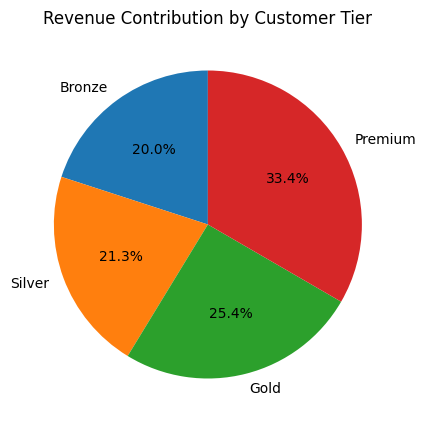

In [ ]:
tier_revenue = (
    df.groupby('customer_value_tier')['purchase_amount']
      .sum()
      .reindex(['Bronze','Silver','Gold','Premium'])
)

plt.figure(figsize=(8,5))

plt.pie(
    tier_revenue,
    labels=tier_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Revenue Contribution by Customer Tier")

plt.show()

Premium customers may represent a smaller portion of the customer base while contributing a disproportionately larger share of revenue.

This helps businesses prioritize customer retention efforts.

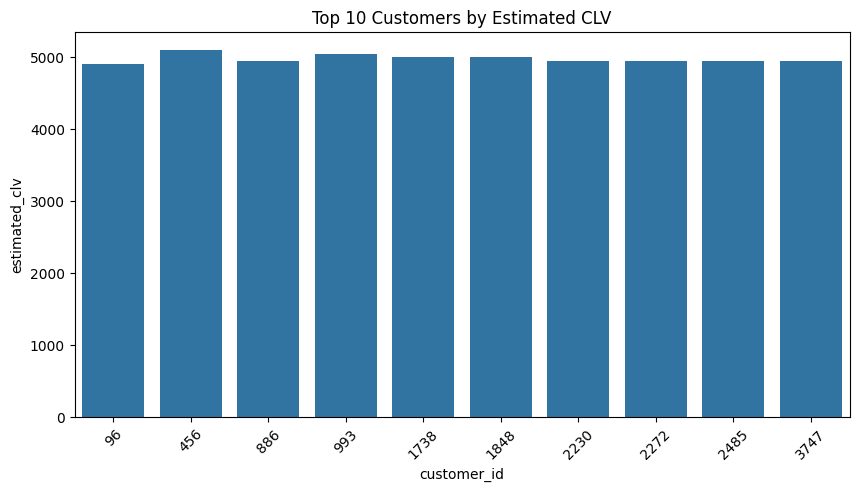

In [ ]:
top_customers = (
    df.sort_values(
        by='estimated_clv',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_customers,
    x='customer_id',
    y='estimated_clv'
)

plt.title("Top 10 Customers by Estimated CLV")

plt.xticks(rotation=45)

plt.show()

Identifying the highest-value customers enables businesses to deliver personalized experiences and maximize long-term profitability.

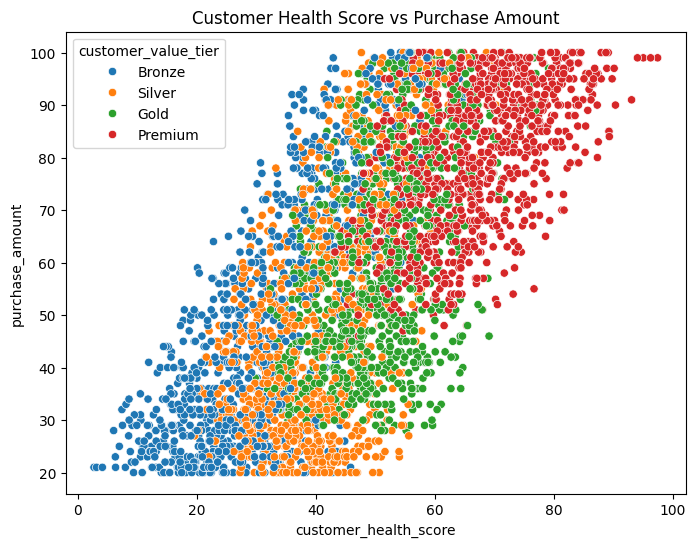

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='customer_health_score',
    y='purchase_amount',
    hue='customer_value_tier'
)

plt.title("Customer Health Score vs Purchase Amount")

plt.show()

Customers with higher health scores generally exhibit higher purchase amounts, indicating stronger engagement and long-term value.

In [ ]:
total_revenue = df['purchase_amount'].sum()

avg_purchase = df['purchase_amount'].mean()

total_customers = df['customer_id'].nunique()

avg_rating = df['review_rating'].mean()

print("========== EXECUTIVE SUMMARY ==========")

print(f"Total Customers      : {total_customers}")

print(f"Total Revenue        : ${total_revenue:,.2f}")

print(f"Average Purchase     : ${avg_purchase:.2f}")

print(f"Average Rating       : {avg_rating:.2f}")

========== EXECUTIVE SUMMARY ==========
Total Customers      : 3900
Total Revenue        : $233,081.00
Average Purchase     : $59.76
Average Rating       : 3.75


## Executive Summary

The customer dataset contains diverse purchasing behaviors across multiple demographic groups and product categories.

Key observations include:

- High-value customers contribute disproportionately to revenue.
- Customer health scores provide a consolidated measure of engagement.
- Premium customer segments represent valuable opportunities for retention.
- Revenue patterns vary across categories, payment methods, seasons, and locations.

These insights provide a strong foundation for business intelligence and strategic decision-making.

# Customer Segmentation using Machine Learning

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Selecting Features for Customer Segmentation

In [ ]:
features = df[
    [
        'purchase_amount',
        'previous_purchases',
        'review_rating',
        'estimated_clv',
        'customer_health_score'
    ]
]

features.head()

,purchase_amount,previous_purchases,review_rating,estimated_clv,customer_health_score
0,53,14,3.1,795,39.26
1,64,2,3.1,192,37.41
2,73,23,3.1,1752,54.77
3,90,49,3.5,4500,82.39
4,49,31,2.7,1568,44.47


The selected features capture customer spending, loyalty, satisfaction, long-term value, and overall engagement. These variables provide a comprehensive representation of customer behavior for segmentation.

In [ ]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [ ]:
scaled_features[:5]

array([[-0.28562864, -0.78583067, -0.91107645, -0.69269333, -0.4933806 ],
       [ 0.17885219, -1.61655226, -0.91107645, -1.22639131, -0.60426405],
       [ 0.55888195, -0.16278948, -0.91107645,  0.1543199 ,  0.4362422 ],
       [ 1.27671595,  1.63710729, -0.35045825,  2.5864958 ,  2.09170204],
       [-0.45453076,  0.39102491, -1.47169465, -0.00853322, -0.18110885]])

## Finding the Optimal Number of Clusters

In [ ]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

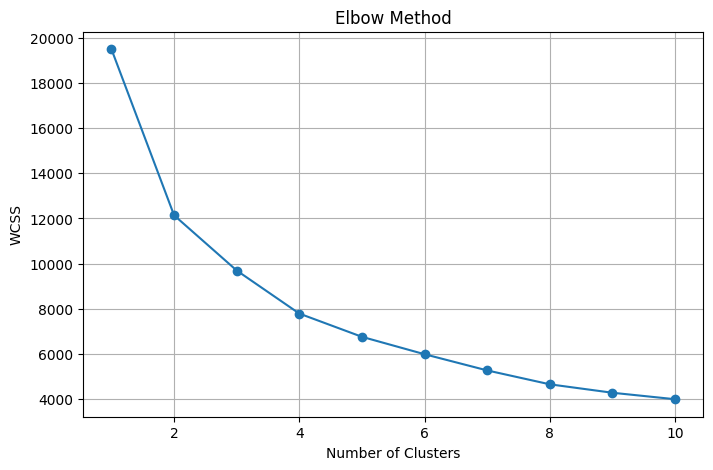

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Business Insight

The Elbow Method identifies the optimal number of customer segments by analyzing the reduction in within-cluster variation. The point where the curve begins to flatten indicates the most suitable number of clusters.

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(
    scaled_features
)

In [ ]:
df[['customer_id','cluster']].head()

,customer_id,cluster
0,1,0
1,2,0
2,3,1
3,4,2
4,5,3


In [ ]:
df['cluster'].value_counts().sort_index()

,count
cluster,
0,970
1,975
2,941
3,1014


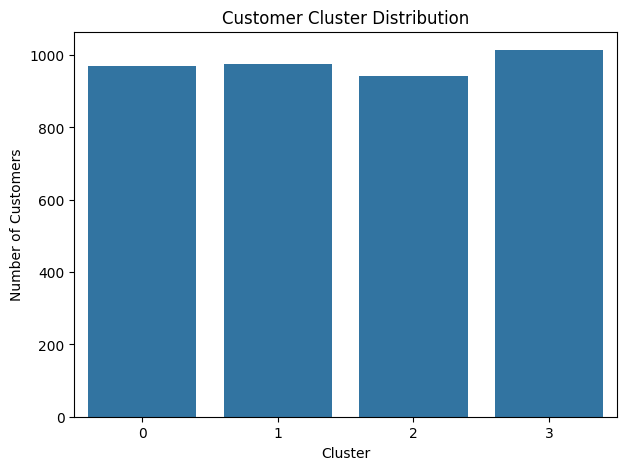

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='cluster'
)

plt.title("Customer Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

### Business Insight

The customer distribution across clusters reveals how customers naturally group based on spending behavior, purchase history, satisfaction, and long-term value.

Balanced clusters indicate meaningful segmentation that can support personalized marketing strategies.

In [ ]:
cluster_summary = (
    df.groupby('cluster')[
        [
            'purchase_amount',
            'previous_purchases',
            'review_rating',
            'estimated_clv',
            'customer_health_score'
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,purchase_amount,previous_purchases,review_rating,estimated_clv,customer_health_score
cluster,,,,,
0,38.08,12.91,3.57,500.42,26.85
1,77.98,13.23,3.88,1084.74,50.31
2,81.91,38.58,3.89,3211.45,68.12
3,42.44,36.63,3.67,1565.87,45.39


/tmp/ipykernel_1021/481266178.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


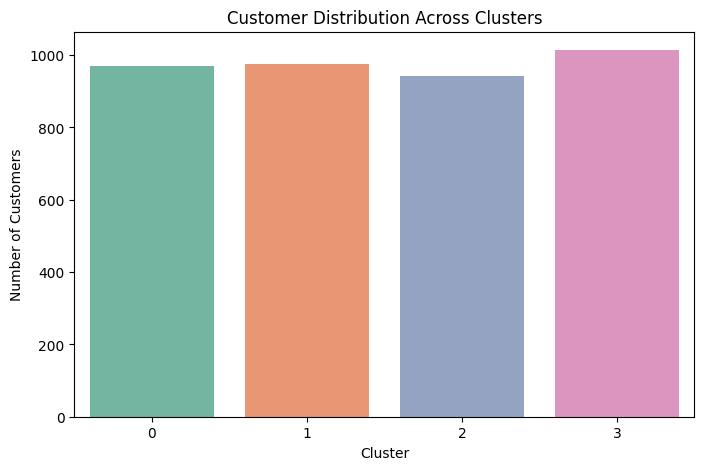

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='cluster',
    palette='Set2'
)

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

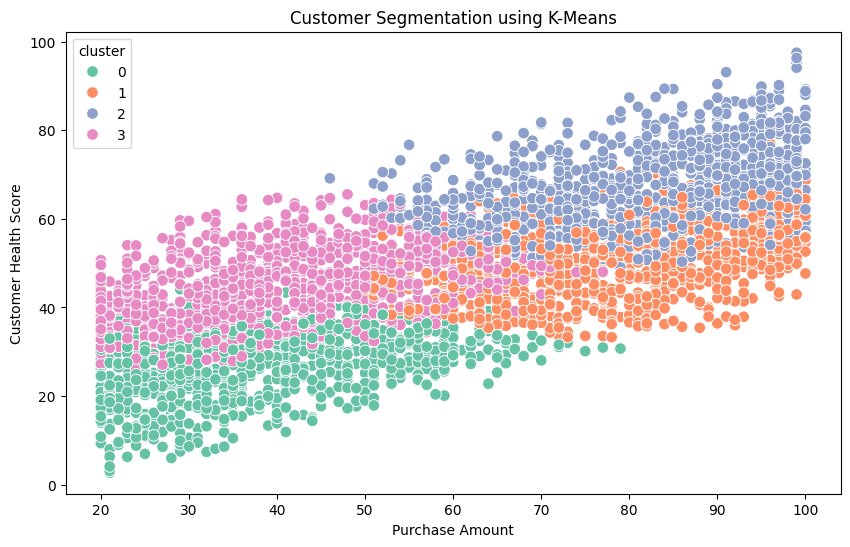

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='purchase_amount',
    y='customer_health_score',
    hue='cluster',
    palette='Set2',
    s=70
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Purchase Amount")
plt.ylabel("Customer Health Score")

plt.show()

### Business Insight

K-Means clustering groups customers with similar purchasing behavior and engagement patterns. This enables businesses to create targeted marketing campaigns, improve customer retention, and allocate resources more effectively.

### Business Recommendation

Each customer segment should receive personalized marketing strategies. High-value customers can be rewarded with loyalty programs, while lower-engagement customers can be targeted with reactivation campaigns.

In [ ]:
cluster_names = {
    0: "At-Risk Customers",
    1: "High-Spending Customers",
    2: "Premium Customers",
    3: "Loyal Customers"
}

df['customer_segment'] = df['cluster'].map(cluster_names)

In [ ]:
df[['cluster', 'customer_segment']].drop_duplicates().sort_values('cluster')

,cluster,customer_segment
0,0,At-Risk Customers
2,1,High-Spending Customers
3,2,Premium Customers
4,3,Loyal Customers


/tmp/ipykernel_1021/2107593272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


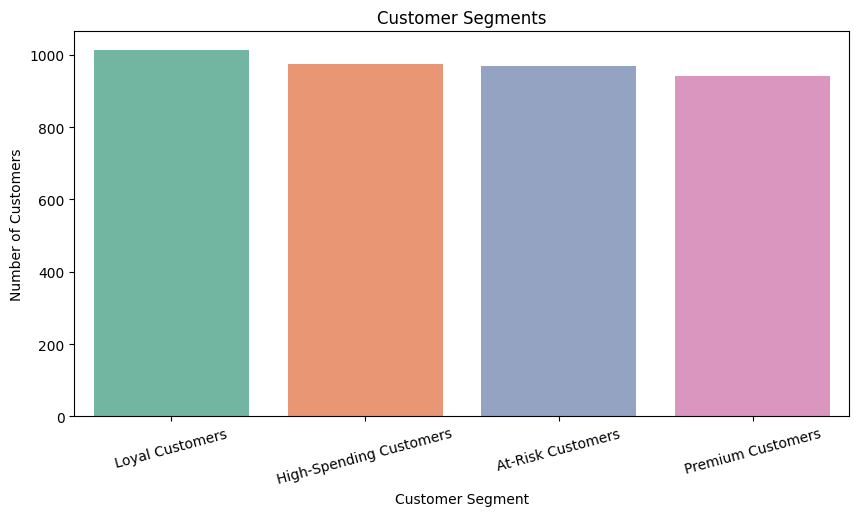

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='customer_segment',
    order=df['customer_segment'].value_counts().index,
    palette='Set2'
)

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Business Insight

Customer segmentation categorizes customers based on their purchasing behavior and engagement levels.

- **Premium Customers** generate the highest lifetime value and should be prioritized for retention.
- **Loyal Customers** purchase frequently and can be encouraged to increase basket value through upselling.
- **High-Spending Customers** spend more per purchase but need strategies to improve repeat purchases.
- **At-Risk Customers** have low engagement and require targeted promotional campaigns to prevent churn.

/tmp/ipykernel_1021/2378297712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


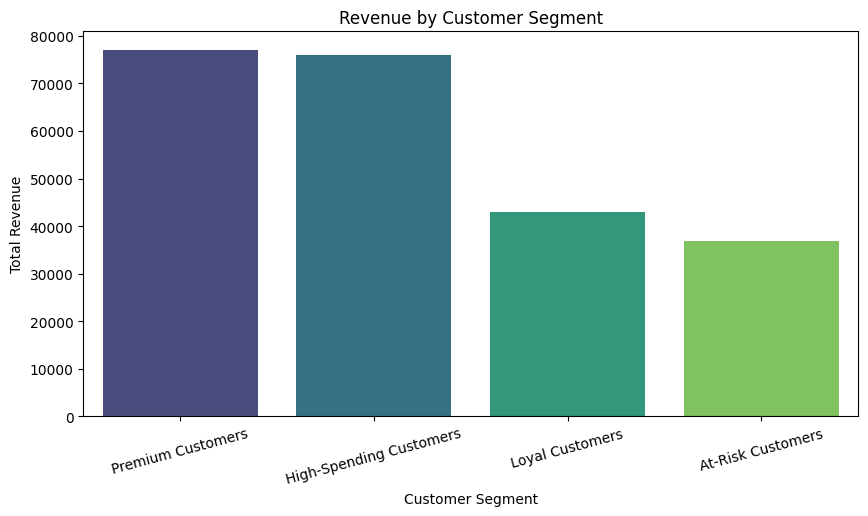

In [ ]:
segment_revenue = (
    df.groupby('customer_segment')['purchase_amount']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values,
    palette='viridis'
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=15)

plt.show()

/tmp/ipykernel_1021/1614850551.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


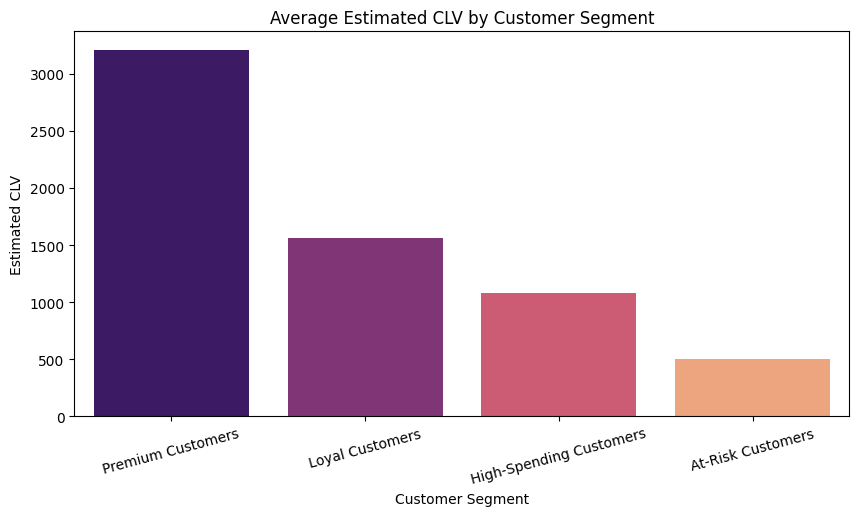

In [ ]:
segment_clv = (
    df.groupby('customer_segment')['estimated_clv']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=segment_clv.index,
    y=segment_clv.values,
    palette='magma'
)

plt.title("Average Estimated CLV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Estimated CLV")

plt.xticks(rotation=15)

plt.show()

In [ ]:
segment_profile = (
    df.groupby('customer_segment')
      .agg({
          'customer_id':'count',
          'purchase_amount':'mean',
          'previous_purchases':'mean',
          'review_rating':'mean',
          'estimated_clv':'mean',
          'customer_health_score':'mean'
      })
      .round(2)
      .rename(columns={'customer_id':'customer_count'})
)

segment_profile

,customer_count,purchase_amount,previous_purchases,review_rating,estimated_clv,customer_health_score
customer_segment,,,,,,
At-Risk Customers,970,38.08,12.91,3.57,500.42,26.85
High-Spending Customers,975,77.98,13.23,3.88,1084.74,50.31
Loyal Customers,1014,42.44,36.63,3.67,1565.87,45.39
Premium Customers,941,81.91,38.58,3.89,3211.45,68.12


# Business Recommendations Based on Customer Segmentation

### Premium Customers
- Provide VIP membership and exclusive rewards.
- Offer early access to new products and personalized recommendations.

### Loyal Customers
- Encourage higher spending through bundle offers and cross-selling.
- Strengthen loyalty programs to maintain engagement.

### High-Spending Customers
- Focus on improving purchase frequency with personalized promotions and reminders.
- Recommend complementary products to increase long-term value.

### At-Risk Customers
- Launch targeted discount campaigns and re-engagement emails.
- Analyze reasons for low engagement and improve customer experience.